# Experiment: Twitch Sarcasm Detection Baseline Comparison

This notebook compares `TF-IDF + Logistic Regression`, a `Bidirectional LSTM`, and an encoder-only `Transformer` on the binary Twitch sarcasm task.

Study scope:
- keep only `sarcasm` and `regular` labels
- apply one shared preprocessing pipeline
- compare the models with accuracy, precision, recall, F1, confusion matrices, and representative errors


In [1]:
# Setup: verify runtime dependencies for this notebook
import importlib.util
import sys
from textwrap import dedent

REQUIRED_PACKAGES = {
    "numpy": "numpy",
    "pandas": "pandas",
    "sklearn": "scikit-learn",
    "matplotlib": "matplotlib",
    "seaborn": "seaborn",
    "torch": "torch",
    "IPython": "ipython",
}

missing_packages = [
    package_name
    for module_name, package_name in REQUIRED_PACKAGES.items()
    if importlib.util.find_spec(module_name) is None
]

if missing_packages:
    raise ModuleNotFoundError(
        dedent(
            f"""
            Missing notebook dependencies: {', '.join(missing_packages)}

            Create and select a local virtualenv kernel before rerunning this notebook:
              {sys.executable} -m venv .venv
              source .venv/bin/activate
              python -m pip install --upgrade pip
              python -m pip install -r requirements-notebooks.txt
              python -m ipykernel install --user --name aml-project

            Then switch the notebook kernel to `aml-project`.
            """.strip()
        )
    )
else:
    print("All required packages are already installed in the active kernel.")


Installing missing packages: seaborn



[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


In [2]:
# Imports, reproducibility, and configuration
from __future__ import annotations

import copy
import html
import math
import random
import re
import unicodedata
import warnings
from collections import Counter
from pathlib import Path
from zipfile import ZipFile

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
from IPython.display import Markdown, display
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score, precision_score, recall_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from torch.nn.utils.rnn import pack_padded_sequence
from torch.utils.data import DataLoader, Dataset

warnings.filterwarnings("ignore")

SEED = 7
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

if hasattr(torch, "set_float32_matmul_precision"):
    torch.set_float32_matmul_precision("high")

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 12


def find_project_root() -> Path:
    dataset_indicators = [
        Path("Dataset") / "Twitch" / "train.csv",
        Path("Dataset") / "Twitch" / "test.csv",
        Path("Dataset") / "Twitch.zip",
    ]
    for candidate in [Path.cwd(), *Path.cwd().parents]:
        if any((candidate / relative_path).exists() for relative_path in dataset_indicators):
            return candidate
    raise FileNotFoundError(
        "Could not locate the project root. Expected Dataset/Twitch/train.csv and Dataset/Twitch/test.csv, "
        "or a Dataset/Twitch.zip archive."
    )


PROJECT_ROOT = find_project_root()
TRAIN_PATH = PROJECT_ROOT / "Dataset" / "Twitch" / "train.csv"
TEST_PATH = PROJECT_ROOT / "Dataset" / "Twitch" / "test.csv"
TWITCH_ARCHIVE_PATH = PROJECT_ROOT / "Dataset" / "Twitch.zip"
LABEL_MAP = {"regular": 0, "sarcasm": 1}
LABEL_NAMES = {0: "regular", 1: "sarcasm"}

CONFIG = {
    "seed": SEED,
    "validation_size": 0.15,
    "max_vocab_size": 15000,
    "min_token_frequency": 2,
    "batch_size": 128,
    "embedding_dim": 128,
    "hidden_dim": 128,
    "lstm_layers": 1,
    "transformer_layers": 2,
    "transformer_heads": 4,
    "transformer_ff_dim": 256,
    "dropout": 0.25,
    "learning_rate": 1e-3,
    "weight_decay": 1e-4,
    "epochs": 8,
    "early_stopping_patience": 2,
    "gradient_clip": 1.0,
    "max_length": None,
}

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")
pd.set_option("display.max_colwidth", 140)


Using device: cpu


## Study Design

Comparison dimensions:
- dataset filtering choices
- vocabulary size and sequence length
- validation versus test performance across the three models

Recorded metrics:
- accuracy
- precision
- recall
- F1-score
- confusion matrices
- representative false positives and false negatives


In [3]:
display(Markdown("### Active configuration"))
pd.DataFrame([CONFIG]).T.rename(columns={0: "value"})


### Active configuration

,value
seed,7
validation_size,0.15
max_vocab_size,15000
min_token_frequency,2
batch_size,128
embedding_dim,128
hidden_dim,128
lstm_layers,1
transformer_layers,2
transformer_heads,4


## Project Framing

This notebook implements the first report-ready version of the project using a conservative binary setup on the Twitch dataset:

- Keep only `sarcasm` and `regular` rows.
- Map `sarcasm -> 1` and `regular -> 0`.
- Drop `irony`, `figurative`, blank labels, and empty rows.

That gives us a clean classification task while staying aligned with the wording of the project template and the chosen method table.


In [4]:
# Shared text preprocessing and dataset helpers
URL_PATTERN = re.compile(r"https?://\S+|www\.\S+")
MENTION_PATTERN = re.compile(r"@\w+")
HASHTAG_PATTERN = re.compile(r"#(\w+)")
TOKEN_PATTERN = re.compile(r"<url>|<user>|hashtag_[a-z0-9_]+|[a-z0-9']+|[!?.,;:()]+")


def normalize_text(text: str) -> str:
    """Normalize tweets while preserving sarcasm-relevant cues."""
    if not isinstance(text, str):
        return ""
    text = html.unescape(text)
    text = unicodedata.normalize("NFKC", text)
    text = text.lower().strip()
    text = URL_PATTERN.sub(" <url> ", text)
    text = MENTION_PATTERN.sub(" <user> ", text)
    text = HASHTAG_PATTERN.sub(lambda match: f" hashtag_{match.group(1)} ", text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()


def tokenize_text(text: str) -> list[str]:
    """Tokenize normalized text into words, placeholders, and punctuation cues."""
    if not text:
        return []
    return TOKEN_PATTERN.findall(text)


def read_twitch_split(csv_path: Path, archive_path: Path, member_name: str) -> pd.DataFrame:
    """Read a Twitch split from an extracted CSV or directly from the zip archive."""
    if csv_path.exists():
        return pd.read_csv(csv_path)
    if archive_path.exists():
        with ZipFile(archive_path) as zip_file:
            with zip_file.open(member_name) as handle:
                return pd.read_csv(handle)
    raise FileNotFoundError(
        "Twitch data not found. Provide Dataset/Twitch/train.csv and Dataset/Twitch/test.csv, "
        "or place the original archive at Dataset/Twitch.zip."
    )


def load_twitch_binary_data(
    train_path: Path,
    test_path: Path,
    archive_path: Path,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    """Load Twitch data and keep only regular vs sarcasm examples."""

    def prepare_split(frame: pd.DataFrame, split_name: str) -> pd.DataFrame:
        frame = frame.rename(columns={"tweets": "tweet", "class": "label_name"}).copy()
        frame = frame[frame["label_name"].isin(LABEL_MAP)].copy()
        frame["tweet"] = frame["tweet"].fillna("").astype(str).str.strip()
        frame = frame[frame["tweet"] != ""].copy()
        frame["normalized_text"] = frame["tweet"].map(normalize_text)
        frame["tokens"] = frame["normalized_text"].map(tokenize_text)
        frame["token_count"] = frame["tokens"].map(len)
        frame = frame[frame["token_count"] > 0].copy()
        frame["label"] = frame["label_name"].map(LABEL_MAP).astype(int)
        frame["split"] = split_name
        return frame.reset_index(drop=True)

    train_df = prepare_split(read_twitch_split(train_path, archive_path, "train.csv"), "train")
    test_df = prepare_split(read_twitch_split(test_path, archive_path, "test.csv"), "test")
    return train_df, test_df


def build_vocab(
    texts: pd.Series,
    min_frequency: int = 2,
    max_vocab_size: int | None = None,
) -> tuple[dict[str, int], Counter]:
    """Build a vocabulary from training text only."""
    counter = Counter()
    for text in texts:
        counter.update(tokenize_text(text))

    vocab = {"<pad>": 0, "<unk>": 1}
    for token, count in counter.most_common():
        if count < min_frequency:
            continue
        if max_vocab_size is not None and len(vocab) >= max_vocab_size:
            break
        vocab[token] = len(vocab)
    return vocab, counter


def encode_and_pad(
    texts: pd.Series,
    vocab: dict[str, int],
    max_length: int,
) -> tuple[np.ndarray, np.ndarray]:
    """Convert text to fixed-length token id arrays."""
    sequences: list[list[int]] = []
    lengths: list[int] = []
    unk_idx = vocab["<unk>"]
    pad_idx = vocab["<pad>"]

    for text in texts:
        token_ids = [vocab.get(token, unk_idx) for token in tokenize_text(text)]
        token_ids = token_ids[:max_length]
        effective_length = max(1, len(token_ids))
        if not token_ids:
            token_ids = [unk_idx]
        padded = token_ids + [pad_idx] * (max_length - len(token_ids))
        sequences.append(padded[:max_length])
        lengths.append(min(effective_length, max_length))

    return np.asarray(sequences, dtype=np.int64), np.asarray(lengths, dtype=np.int64)


def compute_classification_metrics(y_true, y_pred) -> dict[str, float]:
    """Compute standard binary classification metrics."""
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
    }


def show_confusion_matrix(y_true, y_pred, title: str, ax=None):
    """Visualize a confusion matrix using seaborn."""
    matrix = confusion_matrix(y_true, y_pred)
    if ax is None:
        _, ax = plt.subplots(figsize=(4, 4))
    sns.heatmap(
        matrix,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=False,
        xticklabels=[LABEL_NAMES[0], LABEL_NAMES[1]],
        yticklabels=[LABEL_NAMES[0], LABEL_NAMES[1]],
        ax=ax,
    )
    ax.set_title(title)
    ax.set_xlabel("Predicted label")
    ax.set_ylabel("True label")
    return ax


def collect_error_cases(
    frame: pd.DataFrame,
    predictions: np.ndarray,
    probabilities: np.ndarray,
    model_name: str,
    top_n: int = 5,
) -> pd.DataFrame:
    """Collect the most confident false positives and false negatives."""
    analysis_df = frame[["tweet", "label", "label_name", "normalized_text"]].copy()
    analysis_df["predicted_label"] = predictions.astype(int)
    analysis_df["predicted_label_name"] = analysis_df["predicted_label"].map(LABEL_NAMES)
    analysis_df["predicted_probability"] = probabilities
    analysis_df["confidence"] = np.where(
        analysis_df["predicted_label"] == 1,
        analysis_df["predicted_probability"],
        1.0 - analysis_df["predicted_probability"],
    )
    errors = analysis_df[analysis_df["predicted_label"] != analysis_df["label"]].copy()
    errors["error_type"] = np.where(errors["label"] == 1, "false_negative", "false_positive")
    return (
        errors.sort_values(["error_type", "confidence"], ascending=[True, False])
        .groupby("error_type", group_keys=False)
        .head(top_n)
        .reset_index(drop=True)
    )


In [5]:
# Load and validate the binary Twitch setup
train_df, test_df = load_twitch_binary_data(TRAIN_PATH, TEST_PATH, TWITCH_ARCHIVE_PATH)

expected_counts = {"train": 39276, "test": 3964}
observed_counts = {"train": len(train_df), "test": len(test_df)}
for split_name, expected_count in expected_counts.items():
    observed_count = observed_counts[split_name]
    print(f"{split_name}: observed={observed_count:,}, expected={expected_count:,}")
    assert observed_count == expected_count, f"Unexpected count for {split_name}: {observed_count}"

combined_summary = (
    pd.concat([train_df, test_df], ignore_index=True)
    .groupby(["split", "label_name"])
    .size()
    .rename("count")
    .reset_index()
)
display(combined_summary)
display(train_df[["tweet", "normalized_text", "label_name"]].head(5))


train: observed=39,276, expected=39,276
test: observed=3,964, expected=3,964


,split,label_name,count
0,test,regular,1859
1,test,sarcasm,2105
2,train,regular,18595
3,train,sarcasm,20681


,tweet,normalized_text,label_name
0,New #quote : It's both a blessing and a curse to feel so much. #mondayinspiration #late #quote #emotion #feel #emp… http://t.co/5zLIMGgH70,new hashtag_quote : it's both a blessing and a curse to feel so much. hashtag_mondayinspiration hashtag_late hashtag_quote hashtag_emoti...,regular
1,"Daddy Uncle Bubba (#life, love, loss, #laughter &amp; Parkinson's): #DreamTherapy http://t.co/VsJWnJin5i #parkie #late #coach #basketball #","daddy uncle bubba ( hashtag_life , love, loss, hashtag_laughter & parkinson's): hashtag_dreamtherapy <url> hashtag_parkie hashtag_late h...",regular
2,Ayvee - Where Im From on #SoundCloud #late #night #musicafterdark #banger #rap #hip #hop #drake #lil #wayne #hot #np https://t.co/59fSxl...,ayvee - where im from on hashtag_soundcloud hashtag_late hashtag_night hashtag_musicafterdark hashtag_banger hashtag_rap hashtag_hip has...,regular
3,#late starting #dinner #tonight but here is what I'm #prepping to go in #mushrooms #redpepper… https://t.co/fBikZ7fOBY,hashtag_late starting hashtag_dinner hashtag_tonight but here is what i'm hashtag_prepping to go in hashtag_mushrooms hashtag_redpepper ...,regular
4,@Trillakayy__ happy birthdayyyyy #late 😅,<user> happy birthdayyyyy hashtag_late 😅,regular


## Exploratory Analysis

Before modeling, we check:

- class balance after filtering
- token-length distribution
- a practical maximum sequence length for the neural models

The chosen sequence length should be long enough to cover most tweets without adding unnecessary padding.


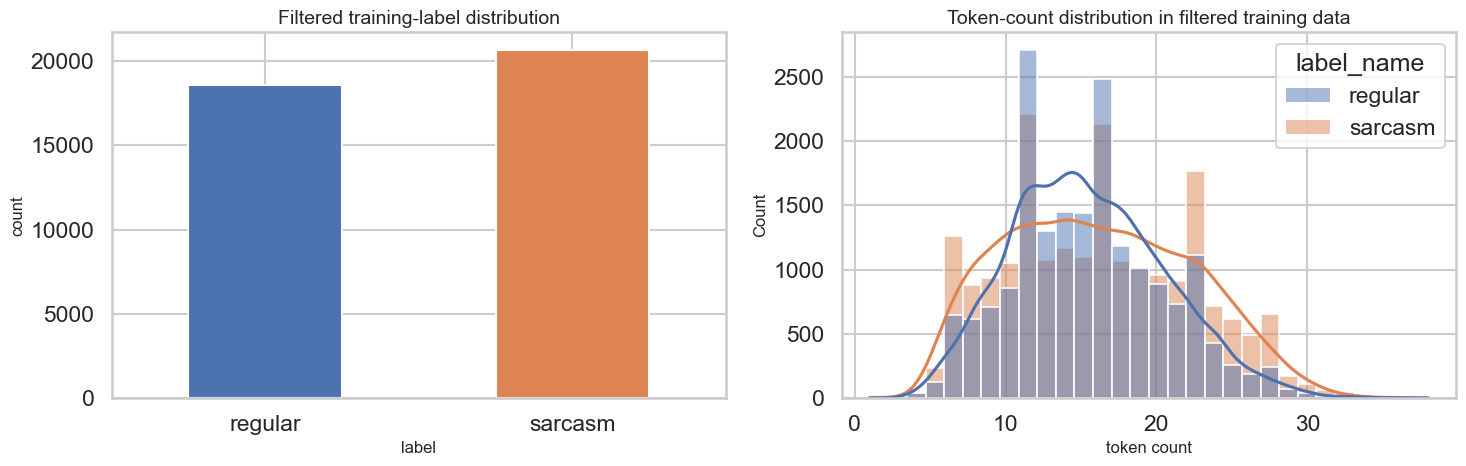

,train_token_count
count,39276.000000
mean,15.848584
std,5.684165
min,1.000000
50%,15.000000
75%,20.000000
90%,24.000000
95%,26.000000
99%,29.000000
max,38.000000


Chosen max sequence length for neural models: 26


In [6]:
# Class balance and text-length inspection
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

train_counts = train_df["label_name"].value_counts().reindex(["regular", "sarcasm"])
train_counts.plot(kind="bar", color=["#4C72B0", "#DD8452"], ax=axes[0])
axes[0].set_title("Filtered training-label distribution")
axes[0].set_xlabel("label")
axes[0].set_ylabel("count")
axes[0].tick_params(axis="x", rotation=0)

sns.histplot(
    data=train_df,
    x="token_count",
    hue="label_name",
    bins=30,
    multiple="layer",
    kde=True,
    ax=axes[1],
)
axes[1].set_title("Token-count distribution in filtered training data")
axes[1].set_xlabel("token count")

plt.tight_layout()
plt.show()

length_summary = train_df["token_count"].describe(percentiles=[0.5, 0.75, 0.9, 0.95, 0.99]).to_frame("train_token_count")
display(length_summary)

derived_max_length = int(np.percentile(train_df["token_count"], 95))
CONFIG["max_length"] = max(12, min(40, derived_max_length))
print(f"Chosen max sequence length for neural models: {CONFIG['max_length']}")


## Shared Preprocessing And Split Strategy

We keep the provided Twitch `test.csv` as the final holdout split and create a stratified validation split from the filtered training rows. This gives us:

- training data for fitting the models
- validation data for early stopping and hyperparameter sanity checks
- untouched test data for the final comparison


In [7]:
train_split_df, val_df = train_test_split(
    train_df,
    test_size=CONFIG["validation_size"],
    stratify=train_df["label"],
    random_state=SEED,
)

train_split_df = train_split_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

split_overview = pd.DataFrame(
    [
        {
            "split": "train",
            "rows": len(train_split_df),
            "sarcasm_share": train_split_df["label"].mean(),
            "avg_token_count": train_split_df["token_count"].mean(),
        },
        {
            "split": "validation",
            "rows": len(val_df),
            "sarcasm_share": val_df["label"].mean(),
            "avg_token_count": val_df["token_count"].mean(),
        },
        {
            "split": "test",
            "rows": len(test_df),
            "sarcasm_share": test_df["label"].mean(),
            "avg_token_count": test_df["token_count"].mean(),
        },
    ]
)
display(split_overview)


,split,rows,sarcasm_share,avg_token_count
0,train,33384,0.526570,15.848880
1,validation,5892,0.526477,15.846911
2,test,3964,0.531029,15.956609


## TF-IDF + Logistic Regression

This is the lexical baseline from the report table. It ignores word order and deeper context, but it is fast, interpretable, and often strong enough to anchor the rest of the comparison.


In [8]:
# Baseline model
results_records = []

tfidf_baseline = Pipeline(
    steps=[
        (
            "tfidf",
            TfidfVectorizer(
                ngram_range=(1, 2),
                min_df=2,
                max_features=20000,
                sublinear_tf=True,
            ),
        ),
        (
            "classifier",
            LogisticRegression(
                max_iter=1000,
                random_state=SEED,
            ),
        ),
    ]
)

tfidf_baseline.fit(train_split_df["normalized_text"], train_split_df["label"])

baseline_predictions = {}
baseline_probabilities = {}

for split_name, split_frame in {
    "validation": val_df,
    "test": test_df,
}.items():
    probabilities = tfidf_baseline.predict_proba(split_frame["normalized_text"])[:, 1]
    predictions = (probabilities >= 0.5).astype(int)
    metrics = compute_classification_metrics(split_frame["label"], predictions)
    metrics.update({"model": "TF-IDF + Logistic Regression", "split": split_name})
    results_records.append(metrics)
    baseline_predictions[split_name] = predictions
    baseline_probabilities[split_name] = probabilities

baseline_results_df = pd.DataFrame(results_records)
display(baseline_results_df)


,accuracy,precision,recall,f1,model,split
0,0.999661,1.0,0.999355,0.999678,TF-IDF + Logistic Regression,validation
1,0.999748,1.0,0.999525,0.999762,TF-IDF + Logistic Regression,test


## Shared Sequence Pipeline For Neural Models

The BiLSTM and the Transformer will use:

- the same normalized input text
- the same training-built vocabulary
- the same maximum sequence length
- the same train / validation / test split

This keeps the comparison focused on architecture rather than data leakage or inconsistent preprocessing.


In [9]:
# Vocabulary construction and sequence encoding
vocab, token_counter = build_vocab(
    train_split_df["normalized_text"],
    min_frequency=CONFIG["min_token_frequency"],
    max_vocab_size=CONFIG["max_vocab_size"],
)

PAD_IDX = vocab["<pad>"]
UNK_IDX = vocab["<unk>"]

print(f"Vocabulary size (including special tokens): {len(vocab):,}")
print("Most common tokens:", token_counter.most_common(15))


class TextClassificationDataset(Dataset):
    """Fixed-length text classification dataset."""

    def __init__(self, input_ids: np.ndarray, lengths: np.ndarray, labels: np.ndarray):
        self.input_ids = torch.tensor(input_ids, dtype=torch.long)
        self.lengths = torch.tensor(lengths, dtype=torch.long)
        self.labels = torch.tensor(labels, dtype=torch.float32)

    def __len__(self) -> int:
        return len(self.labels)

    def __getitem__(self, idx: int):
        return self.input_ids[idx], self.lengths[idx], self.labels[idx]


def make_sequence_dataset(frame: pd.DataFrame) -> TextClassificationDataset:
    input_ids, lengths = encode_and_pad(frame["normalized_text"], vocab, CONFIG["max_length"])
    labels = frame["label"].to_numpy(dtype=np.float32)
    return TextClassificationDataset(input_ids, lengths, labels)


train_dataset = make_sequence_dataset(train_split_df)
val_dataset = make_sequence_dataset(val_df)
test_dataset = make_sequence_dataset(test_df)

train_loader = DataLoader(train_dataset, batch_size=CONFIG["batch_size"], shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=CONFIG["batch_size"], shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=CONFIG["batch_size"], shuffle=False)

print(f"Train batches: {len(train_loader)}")
print(f"Validation batches: {len(val_loader)}")
print(f"Test batches: {len(test_loader)}")


Vocabulary size (including special tokens): 15,000
Most common tokens: [('<url>', 20571), ('hashtag_sarcasm', 16675), ('.', 16157), ('<user>', 14960), ('the', 11594), ('to', 9085), (',', 8341), ('a', 7520), ('i', 5988), ('...', 5438), ('of', 5360), ('!', 5146), ('is', 4940), ('in', 4922), ('and', 4697)]
Train batches: 261
Validation batches: 47
Test batches: 31


In [10]:
# Shared neural-model training and evaluation helpers
def run_epoch(model, dataloader, criterion, optimizer=None):
    """Run one epoch and return loss, predictions, and metrics."""
    train_mode = optimizer is not None
    model.train(train_mode)

    total_loss = 0.0
    all_probabilities = []
    all_predictions = []
    all_labels = []

    for input_ids, lengths, labels in dataloader:
        input_ids = input_ids.to(DEVICE)
        lengths = lengths.to(DEVICE)
        labels = labels.to(DEVICE)

        if train_mode:
            optimizer.zero_grad()

        with torch.set_grad_enabled(train_mode):
            logits = model(input_ids, lengths)
            loss = criterion(logits, labels)
            if train_mode:
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), CONFIG["gradient_clip"])
                optimizer.step()

        probabilities = torch.sigmoid(logits)
        predictions = (probabilities >= 0.5).long()

        total_loss += loss.item() * labels.size(0)
        all_probabilities.append(probabilities.detach().cpu().numpy())
        all_predictions.append(predictions.detach().cpu().numpy())
        all_labels.append(labels.detach().cpu().numpy())

    y_prob = np.concatenate(all_probabilities)
    y_pred = np.concatenate(all_predictions)
    y_true = np.concatenate(all_labels).astype(int)
    metrics = compute_classification_metrics(y_true, y_pred)
    metrics["loss"] = total_loss / len(dataloader.dataset)
    return metrics, y_prob, y_pred, y_true


def train_neural_model(model, train_loader, val_loader, model_name: str):
    """Train a model with AdamW and early stopping on validation F1."""
    criterion = nn.BCEWithLogitsLoss()
    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=CONFIG["learning_rate"],
        weight_decay=CONFIG["weight_decay"],
    )

    best_state = None
    best_val_f1 = -np.inf
    epochs_without_improvement = 0
    history = []

    for epoch in range(1, CONFIG["epochs"] + 1):
        train_metrics, *_ = run_epoch(model, train_loader, criterion, optimizer=optimizer)
        val_metrics, *_ = run_epoch(model, val_loader, criterion, optimizer=None)

        epoch_record = {
            "model": model_name,
            "epoch": epoch,
            "train_loss": train_metrics["loss"],
            "train_f1": train_metrics["f1"],
            "val_loss": val_metrics["loss"],
            "val_f1": val_metrics["f1"],
            "val_accuracy": val_metrics["accuracy"],
            "val_precision": val_metrics["precision"],
            "val_recall": val_metrics["recall"],
        }
        history.append(epoch_record)

        print(
            f"{model_name} | epoch {epoch:02d} | "
            f"train_loss={train_metrics['loss']:.4f} | train_f1={train_metrics['f1']:.4f} | "
            f"val_loss={val_metrics['loss']:.4f} | val_f1={val_metrics['f1']:.4f}"
        )

        if val_metrics["f1"] > best_val_f1:
            best_val_f1 = val_metrics["f1"]
            best_state = copy.deepcopy(model.state_dict())
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1

        if epochs_without_improvement >= CONFIG["early_stopping_patience"]:
            print(f"Early stopping triggered for {model_name}.")
            break

    if best_state is not None:
        model.load_state_dict(best_state)

    history_df = pd.DataFrame(history)
    return model, history_df


def evaluate_neural_model(model, dataloader, split_name: str, model_name: str):
    """Evaluate a trained neural model on a split."""
    criterion = nn.BCEWithLogitsLoss()
    metrics, probabilities, predictions, labels = run_epoch(
        model,
        dataloader,
        criterion,
        optimizer=None,
    )
    metrics.update({"model": model_name, "split": split_name})
    return metrics, probabilities, predictions, labels


## Bidirectional LSTM

The recurrent model follows the same overall sequence workflow as the RNN lecture material, but adapts it from sequence-to-sequence translation to binary sequence classification.

Architecture:

- learned token embeddings
- bidirectional LSTM encoder
- concatenated forward/backward final states
- dropout
- binary classification head


In [11]:
class BiLSTMClassifier(nn.Module):
    """Bidirectional LSTM text classifier."""

    def __init__(
        self,
        vocab_size: int,
        embedding_dim: int,
        hidden_dim: int,
        num_layers: int,
        dropout: float,
        pad_idx: int,
    ):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=pad_idx)
        self.encoder = nn.LSTM(
            input_size=embedding_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(hidden_dim * 2, 1)

    def forward(self, input_ids: torch.Tensor, lengths: torch.Tensor) -> torch.Tensor:
        embedded = self.embedding(input_ids)
        packed = pack_padded_sequence(
            embedded,
            lengths.cpu(),
            batch_first=True,
            enforce_sorted=False,
        )
        _, (hidden_state, _) = self.encoder(packed)
        forward_hidden = hidden_state[-2]
        backward_hidden = hidden_state[-1]
        features = torch.cat([forward_hidden, backward_hidden], dim=1)
        logits = self.classifier(self.dropout(features)).squeeze(-1)
        return logits


In [12]:
bilstm_model = BiLSTMClassifier(
    vocab_size=len(vocab),
    embedding_dim=CONFIG["embedding_dim"],
    hidden_dim=CONFIG["hidden_dim"],
    num_layers=CONFIG["lstm_layers"],
    dropout=CONFIG["dropout"],
    pad_idx=PAD_IDX,
).to(DEVICE)

bilstm_model, bilstm_history_df = train_neural_model(
    bilstm_model,
    train_loader,
    val_loader,
    model_name="Bidirectional LSTM",
)

bilstm_results = {}
bilstm_predictions = {}
bilstm_probabilities = {}

for split_name, loader in {"validation": val_loader, "test": test_loader}.items():
    metrics, probabilities, predictions, _ = evaluate_neural_model(
        bilstm_model,
        loader,
        split_name=split_name,
        model_name="Bidirectional LSTM",
    )
    results_records.append(metrics)
    bilstm_results[split_name] = metrics
    bilstm_predictions[split_name] = predictions
    bilstm_probabilities[split_name] = probabilities

display(bilstm_history_df)


Bidirectional LSTM | epoch 01 | train_loss=0.0832 | train_f1=0.9717 | val_loss=0.0246 | val_f1=0.9915
Bidirectional LSTM | epoch 02 | train_loss=0.0170 | train_f1=0.9937 | val_loss=0.0219 | val_f1=0.9909
Bidirectional LSTM | epoch 03 | train_loss=0.0098 | train_f1=0.9968 | val_loss=0.0285 | val_f1=0.9896
Early stopping triggered for Bidirectional LSTM.


,model,epoch,train_loss,train_f1,val_loss,val_f1,val_accuracy,val_precision,val_recall
0,Bidirectional LSTM,1,0.083156,0.971745,0.024639,0.991450,0.991005,0.992251,0.990651
1,Bidirectional LSTM,2,0.017027,0.993725,0.021878,0.990947,0.990496,0.993839,0.988072
2,Bidirectional LSTM,3,0.009835,0.996820,0.028539,0.989631,0.989138,0.994788,0.984526


## Encoder-Only Transformer

This classifier mirrors the course Transformer direction more closely:

- token embeddings
- positional encoding
- stacked self-attention encoder layers
- masked mean pooling over valid tokens
- binary classification head


In [13]:
class PositionalEncoding(nn.Module):
    """Sinusoidal positional encoding."""

    def __init__(self, embedding_dim: int, max_length: int):
        super().__init__()
        positions = torch.arange(max_length).unsqueeze(1)
        div_term = torch.exp(
            torch.arange(0, embedding_dim, 2) * (-math.log(10000.0) / embedding_dim)
        )
        pe = torch.zeros(max_length, embedding_dim)
        pe[:, 0::2] = torch.sin(positions * div_term)
        pe[:, 1::2] = torch.cos(positions * div_term)
        self.register_buffer("pe", pe.unsqueeze(0))

    def forward(self, inputs: torch.Tensor) -> torch.Tensor:
        return inputs + self.pe[:, : inputs.size(1)]


class TransformerEncoderClassifier(nn.Module):
    """Encoder-only Transformer text classifier."""

    def __init__(
        self,
        vocab_size: int,
        embedding_dim: int,
        num_heads: int,
        num_layers: int,
        ff_dim: int,
        dropout: float,
        pad_idx: int,
        max_length: int,
    ):
        super().__init__()
        self.pad_idx = pad_idx
        self.embedding_dim = embedding_dim
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=pad_idx)
        self.position = PositionalEncoding(embedding_dim, max_length)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embedding_dim,
            nhead=num_heads,
            dim_feedforward=ff_dim,
            dropout=dropout,
            batch_first=True,
            norm_first=True,
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(embedding_dim, 1)

    def forward(self, input_ids: torch.Tensor, lengths: torch.Tensor) -> torch.Tensor:
        padding_mask = input_ids.eq(self.pad_idx)
        embeddings = self.embedding(input_ids) * math.sqrt(self.embedding_dim)
        encoded = self.position(embeddings)
        encoded = self.encoder(encoded, src_key_padding_mask=padding_mask)

        valid_mask = (~padding_mask).unsqueeze(-1)
        pooled = (encoded * valid_mask).sum(dim=1) / valid_mask.sum(dim=1).clamp(min=1)
        logits = self.classifier(self.dropout(pooled)).squeeze(-1)
        return logits


In [14]:
transformer_model = TransformerEncoderClassifier(
    vocab_size=len(vocab),
    embedding_dim=CONFIG["embedding_dim"],
    num_heads=CONFIG["transformer_heads"],
    num_layers=CONFIG["transformer_layers"],
    ff_dim=CONFIG["transformer_ff_dim"],
    dropout=CONFIG["dropout"],
    pad_idx=PAD_IDX,
    max_length=CONFIG["max_length"],
).to(DEVICE)

transformer_model, transformer_history_df = train_neural_model(
    transformer_model,
    train_loader,
    val_loader,
    model_name="Encoder-only Transformer",
)

transformer_results = {}
transformer_predictions = {}
transformer_probabilities = {}

for split_name, loader in {"validation": val_loader, "test": test_loader}.items():
    metrics, probabilities, predictions, _ = evaluate_neural_model(
        transformer_model,
        loader,
        split_name=split_name,
        model_name="Encoder-only Transformer",
    )
    results_records.append(metrics)
    transformer_results[split_name] = metrics
    transformer_predictions[split_name] = predictions
    transformer_probabilities[split_name] = probabilities

display(transformer_history_df)


Encoder-only Transformer | epoch 01 | train_loss=0.0811 | train_f1=0.9667 | val_loss=0.0200 | val_f1=0.9914
Encoder-only Transformer | epoch 02 | train_loss=0.0156 | train_f1=0.9944 | val_loss=0.0180 | val_f1=0.9918
Encoder-only Transformer | epoch 03 | train_loss=0.0106 | train_f1=0.9962 | val_loss=0.0202 | val_f1=0.9939
Encoder-only Transformer | epoch 04 | train_loss=0.0065 | train_f1=0.9977 | val_loss=0.0249 | val_f1=0.9932
Encoder-only Transformer | epoch 05 | train_loss=0.0036 | train_f1=0.9990 | val_loss=0.0328 | val_f1=0.9929
Early stopping triggered for Encoder-only Transformer.


,model,epoch,train_loss,train_f1,val_loss,val_f1,val_accuracy,val_precision,val_recall
0,Encoder-only Transformer,1,0.081137,0.966653,0.019952,0.991439,0.991005,0.993525,0.989362
1,Encoder-only Transformer,2,0.015572,0.994434,0.018046,0.991770,0.991344,0.992892,0.990651
2,Encoder-only Transformer,3,0.010578,0.996163,0.020243,0.993885,0.993551,0.992288,0.995487
3,Encoder-only Transformer,4,0.006529,0.997697,0.024853,0.993232,0.992872,0.992912,0.993553
4,Encoder-only Transformer,5,0.003616,0.999033,0.032787,0.992903,0.992532,0.993544,0.992263


## Evaluation And Comparison

This section puts all three models side-by-side using the same validation and holdout splits. The key figure for the report is usually the test-set F1-score, but accuracy, precision, recall, and confusion matrices help explain *why* one model wins.


,model,split,accuracy,precision,recall,f1
0,TF-IDF + Logistic Regression,test,0.9997,1.0000,0.9995,0.9998
1,Encoder-only Transformer,test,0.9939,0.9910,0.9976,0.9943
2,Bidirectional LSTM,test,0.9907,0.9905,0.9919,0.9912
3,TF-IDF + Logistic Regression,validation,0.9997,1.0000,0.9994,0.9997
4,Encoder-only Transformer,validation,0.9936,0.9923,0.9955,0.9939
5,Bidirectional LSTM,validation,0.9910,0.9923,0.9907,0.9915


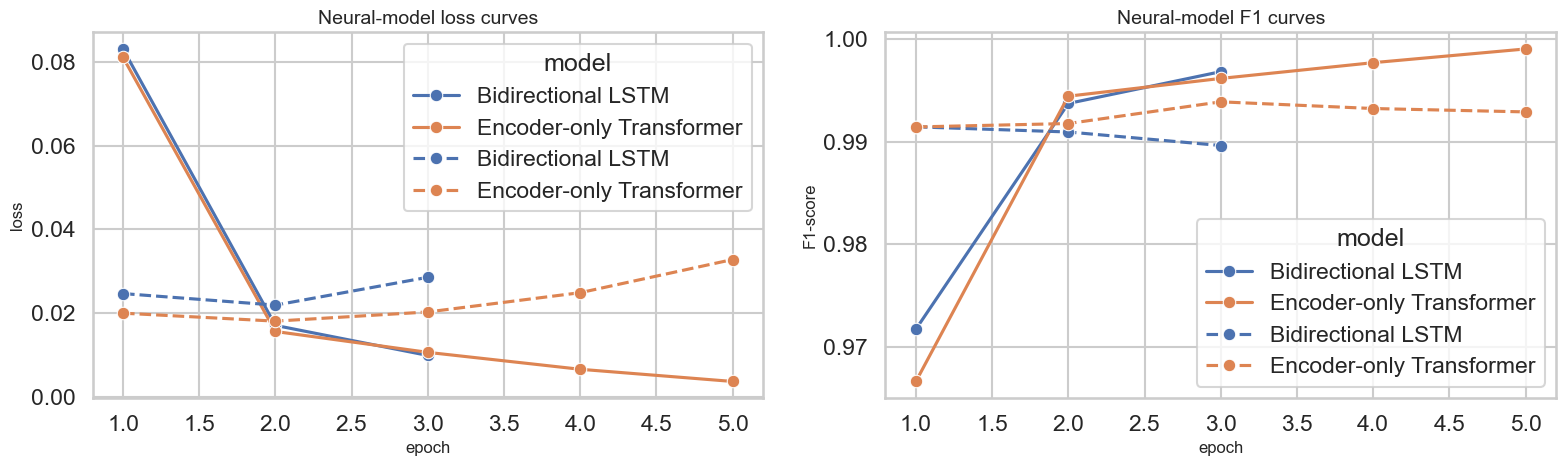

In [15]:
comparison_df = pd.DataFrame(results_records)
comparison_df = comparison_df[
    ["model", "split", "accuracy", "precision", "recall", "f1"]
].sort_values(["split", "f1"], ascending=[True, False]).reset_index(drop=True)

display(comparison_df.style.format({col: "{:.4f}" for col in ["accuracy", "precision", "recall", "f1"]}))

history_plot_df = pd.concat([bilstm_history_df, transformer_history_df], ignore_index=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.lineplot(data=history_plot_df, x="epoch", y="train_loss", hue="model", marker="o", ax=axes[0])
sns.lineplot(data=history_plot_df, x="epoch", y="val_loss", hue="model", marker="o", linestyle="--", ax=axes[0])
axes[0].set_title("Neural-model loss curves")
axes[0].set_ylabel("loss")

sns.lineplot(data=history_plot_df, x="epoch", y="train_f1", hue="model", marker="o", ax=axes[1])
sns.lineplot(data=history_plot_df, x="epoch", y="val_f1", hue="model", marker="o", linestyle="--", ax=axes[1])
axes[1].set_title("Neural-model F1 curves")
axes[1].set_ylabel("F1-score")

plt.tight_layout()
plt.show()


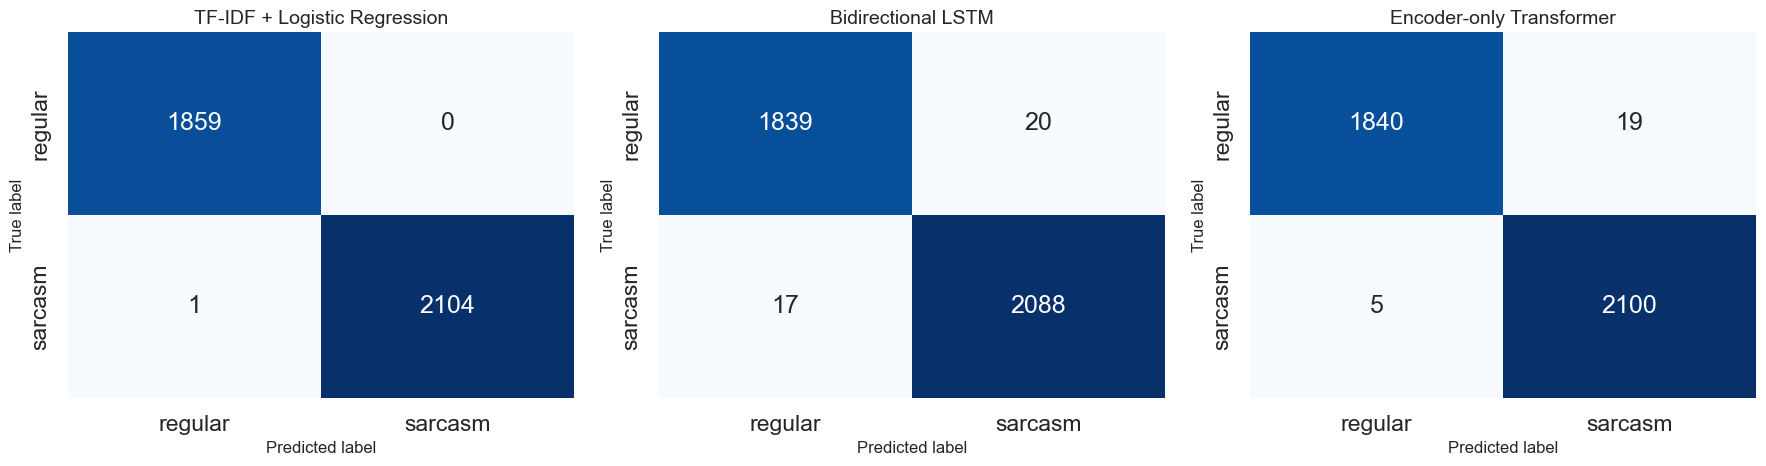

In [16]:
# Test-set confusion matrices for all models
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

show_confusion_matrix(
    test_df["label"],
    baseline_predictions["test"],
    title="TF-IDF + Logistic Regression",
    ax=axes[0],
)
show_confusion_matrix(
    test_df["label"],
    bilstm_predictions["test"],
    title="Bidirectional LSTM",
    ax=axes[1],
)
show_confusion_matrix(
    test_df["label"],
    transformer_predictions["test"],
    title="Encoder-only Transformer",
    ax=axes[2],
)

plt.tight_layout()
plt.show()


## Error Analysis

Metrics alone do not tell the full story for sarcasm detection. Here we collect the most confident mistakes from each model so we can inspect:

- lexical traps that fool the baseline
- sequential cues that help or hurt the BiLSTM
- context-heavy contradictions that may benefit from self-attention


In [17]:
test_error_analysis = pd.concat(
    [
        collect_error_cases(
            test_df,
            baseline_predictions["test"],
            baseline_probabilities["test"],
            model_name="TF-IDF + Logistic Regression",
            top_n=5,
        ),
        collect_error_cases(
            test_df,
            bilstm_predictions["test"],
            bilstm_probabilities["test"],
            model_name="Bidirectional LSTM",
            top_n=5,
        ),
        collect_error_cases(
            test_df,
            transformer_predictions["test"],
            transformer_probabilities["test"],
            model_name="Encoder-only Transformer",
            top_n=5,
        ),
    ],
    ignore_index=True,
)

display(
    test_error_analysis[
        [
            "model",
            "error_type",
            "confidence",
            "label_name",
            "predicted_label_name",
            "tweet",
        ]
    ].sort_values(["model", "error_type", "confidence"], ascending=[True, True, False])
)


,model,error_type,confidence,label_name,predicted_label_name,tweet
6,Bidirectional LSTM,false_negative,0.981795,sarcasm,regular,"Meth is now in 'good ol'' Lewis County...sad, but not shocking. Put up another church! The kids aren't getting enough church!!! #sarcasm"
7,Bidirectional LSTM,false_negative,0.931488,sarcasm,regular,AWESOME 1st day back 2 work for Carol from vacation. Started at 7:45 this morning and she's STILL working on an issue. #sarcasm #helpless
8,Bidirectional LSTM,false_negative,0.864332,sarcasm,regular,"laughing at ppl still post how kimi is underpressure so that ferrari will keep him.\nit is kimi who has the option, ok? not ferrari. #sa..."
9,Bidirectional LSTM,false_negative,0.771942,sarcasm,regular,The future is GLORIOUS! @deadpoolmovie Trailer Officially Released Online http://t.co/tLt8Lpqeij #DeadpoolTrailer #sarcastic
10,Bidirectional LSTM,false_negative,0.739831,sarcasm,regular,"Currently reading #HalfBad, the first of a new youth series. It will have a movie trilogy too, no doubt starring Shailene Woodley. #sarcasm"
1,Bidirectional LSTM,false_positive,0.897552,regular,sarcasm,@h_jasmine that tweet took me a sober time (20s) to tweet...... This one took me a whole minute to type and edit. #drugs
2,Bidirectional LSTM,false_positive,0.891541,regular,sarcasm,"So appropriate after @Oprah #belief event that I am preaching at a synagogue, a church and a mosque on #peace in next few weeks! #belief..."
3,Bidirectional LSTM,false_positive,0.853558,regular,sarcasm,"...you can't hide the evidence of a nuclear reactor. What do you do? Put it in a closet, bury it, or burn the radiation? No, Cruz #GOPDe..."
4,Bidirectional LSTM,false_positive,0.815175,regular,sarcasm,I need to learn to fly so I don't need to rely on @Translink_NI stupid buses. Twice I've had to fork out on taxis :( #annoyed #late
5,Bidirectional LSTM,false_positive,0.809007,regular,sarcasm,"🙏🏽 RT @1Versatyle: @DutchReBelleFN Sis, you did a lovely job on the Kings and Queens track with S-Caliber &amp; me. It's a great look! #..."


## Conclusions

The closing section consolidates:
- the strongest test-set result across the three models
- the main differences between lexical, recurrent, and self-attention-based behavior
- representative error patterns that remain difficult on the Twitch benchmark


In [ ]:
# Minimal summary object to copy into report notes
best_test_row = (
    comparison_df[comparison_df["split"] == "test"]
    .sort_values("f1", ascending=False)
    .iloc[0]
    .to_dict()
)

report_assets = {
    "chosen_sequence_length": CONFIG["max_length"],
    "vocabulary_size": len(vocab),
    "best_test_model": best_test_row["model"],
    "best_test_f1": round(float(best_test_row["f1"]), 4),
    "models_compared": comparison_df["model"].drop_duplicates().tolist(),
}

report_assets
